<a href="https://colab.research.google.com/github/AnaGarcia21/FisicaComputacional/blob/main/Taller6Tarea2_Beta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; La función escogida corresponde a:
$$
f(x) = e^{-x^2},
$$
cuya integral se expresa como:
$$
\int_{a}^{b} e^{-x^2} \, dx.
$$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; En este caso, los intervalos a evaluar son:
$$
\text{A: } [-1, 1] \\
\text{B: } [-2, 2] \\
\text{C: } [-3, 3]
$$

**Pre-ámbulo:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# --- --- --- --- ---
#Funciones:

#Función gaussiana
def gaussiana(x):
  res = np.exp(-(x**2))
  return res

#Segunda derivada
def f2(x):
    return np.exp(-(x**2))*((4*(x**2))-2)

#Integral exacta
def i_exacta(a, b):
  res = (np.sqrt(np.pi)/2)*(special.erf(b)-special.erf(a))
  return res

#np.sqrt(x)
#np.pi

#print(i_exacta(-3, 3))

#Integral por conteo de cajas
def i_cajas(a, b, N):
  h = (b-a)/N

  x_i = a+(h*np.arange(1, N+1))
  f = gaussiana(x_i)

  res = np.sum(f)*h

  return res

#Integral por regla del trapezoide
def i_trapez(a, b, N):
  h = (b-a)/N

  x_i = a+(h*np.arange(0, N+1))
  f = gaussiana(x_i)

  res = (h/2)*(f[0] + 2*np.sum(f[1:-1]) + f[-1])

  return res

#Integral por regla de Simpson
def i_simpson(a, b, N):
  if (N%2) != 0:
    raise ValueError("Error: el N seleccionado debe ser un número par.")

  h = (b-a)/N

  x_i = a+(h*np.arange(0, N+1))
  f = gaussiana(x_i)

  suma = f[0] + f[-1]

  for i in range(1, N):
    if (i%2) != 0:
      suma += 4*f[i]
    elif (i%2) == 0:
      suma += 2*f[i]

  res = (h/3)*suma

  return res

#Cuadratura gaussiana
def cuadr_gauss(a, b, N):
  if N < 1 or N > 5:
        raise ValueError("Error: el N seleccionado debe ser un número de 1 a 5.")

  #Definiendo valores de las variables
  x_i = [
      None,
      [0],                                                                                                                                                #N=1
      [(1/np.sqrt(3)), -(1/np.sqrt(3))],                                                                                                                  #N=2
      [0, (3/np.sqrt(5)), -(3/np.sqrt(5))],                                                                                                               #N=3
      [np.sqrt((3/7)-(2/7)*np.sqrt(6/5)), -np.sqrt((3/7)-(2/7)*np.sqrt(6/5)), np.sqrt((3/7)+(2/7)*np.sqrt(6/5)), -np.sqrt((3/7)+(2/7)*np.sqrt(6/5))],     #N=4
      [0, (1/3)*np.sqrt(5-2*np.sqrt(10/7)), -(1/3)*np.sqrt(5-2*np.sqrt(10/7)), (1/3)*np.sqrt(5+2*np.sqrt(10/7)), -(1/3)*np.sqrt(5+2*np.sqrt(10/7))]       #N=5
  ]

  w_i = [
      None,
      [2],                                                                                                                                                #N=1
      [1, 1],                                                                                                                                             #N=2
      [(8/9), (5/9), (5/9)],                                                                                                                              #N=3
      [((18+np.sqrt(30))/36), ((18+np.sqrt(30))/36), ((18-np.sqrt(30))/36), ((18-np.sqrt(30))/36)],                                                       #N=4
      [(128/225), ((322+13*np.sqrt(70))/900), ((322+13*np.sqrt(70))/900), ((322-13*np.sqrt(70))/900), ((322-13*np.sqrt(70))/900)]                         #N=5
  ]

  #Comportamiento según el intervalo [a, b]
  x_inew = [(((b+a)/2) + ((b-a)/2)*x) for x in x_i[N]]
  w_inew = [(((b-a)/2)*w) for w in w_i[N]]

  f = [gaussiana(x) for x in x_inew]

  suma = 0

  for j in range(len(w_inew)):
    suma += w_inew[j]*f[j]

  return suma

#Error relativo
def error_rel(x_real, x_calculado):
  e_rel = abs(x_real-x_calculado)/x_real
  return e_rel

**Parte 1:**

--- --- ---
Intervalo A:


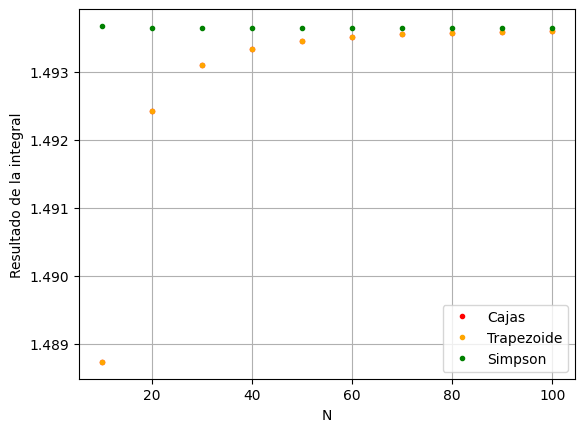

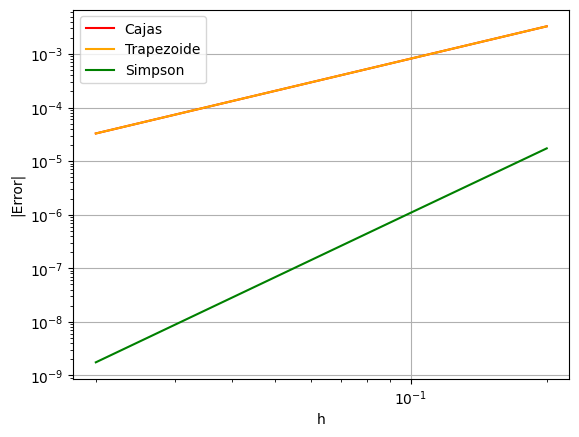

In [ ]:
N = np.arange(10, 110, 10)

# --- --- --- --- ---
#Para A: [−1,1]
h_A = (1-(-1))/N

exacta_A = i_exacta(-1, 1)

cajas_A = []
trapezoide_A = []
simpson_A = []

e_cajas_A = []
e_trapezoide_A = []
e_simpson_A = []

for n in N:
  #Calculo de resultados
  c_A = i_cajas(-1, 1, n)
  t_A = i_trapez(-1, 1, n)
  s_A = i_simpson(-1, 1, n)

  cajas_A.append(c_A)
  trapezoide_A.append(t_A)
  simpson_A.append(s_A)

  #Calculo de errores
  e_c_A = error_rel(exacta_A, c_A)
  e_t_A = error_rel(exacta_A, t_A)
  e_s_A = error_rel(exacta_A, s_A)

  e_cajas_A.append(e_c_A)
  e_trapezoide_A.append(e_t_A)
  e_simpson_A.append(e_s_A)

#Graficamos
#Gráfico de resultados
print("--- --- ---")
print("Intervalo A:")

plt.plot(N, cajas_A, ".", color = "red", label = "Cajas")
plt.plot(N, trapezoide_A, ".", color = "orange", label = "Trapezoide")
plt.plot(N, simpson_A, ".", color = "green", label = "Simpson")

plt.ylabel("Resultado de la integral")
plt.xlabel("N")

plt.legend()
plt.grid()
plt.savefig("A.png", dpi=300, bbox_inches="tight")
plt.show()

#Gráfico de error
plt.loglog(h_A, e_cajas_A, "-", color = "red", label = "Cajas")
plt.loglog(h_A, e_trapezoide_A, "-", color = "orange", label = "Trapezoide")
plt.loglog(h_A, e_simpson_A, "-", color = "green", label = "Simpson")

plt.ylabel("|Error|")
plt.xlabel("h")

plt.legend()
plt.grid()
plt.savefig("eA.png", dpi=300, bbox_inches="tight")
plt.show()

--- --- ---
Intervalo B:


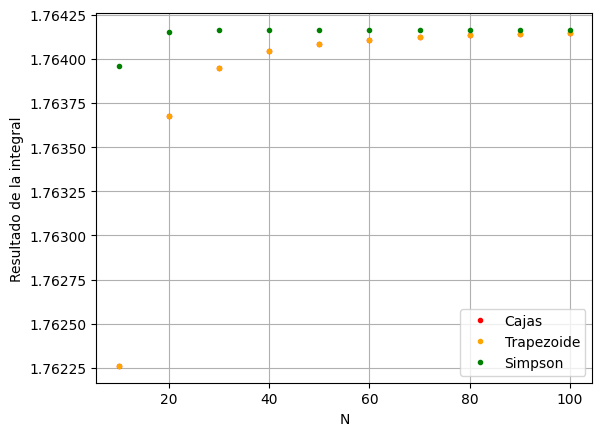

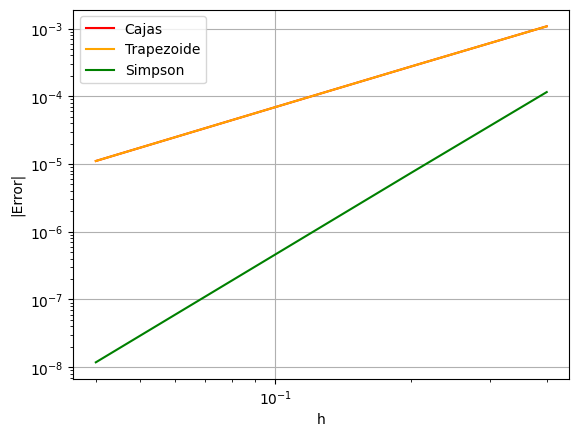

In [ ]:
# --- --- --- --- ---
#Para B: [−2,2]
h_B = (2-(-2))/N

exacta_B = i_exacta(-2, 2)

cajas_B = []
trapezoide_B = []
simpson_B = []

e_cajas_B = []
e_trapezoide_B = []
e_simpson_B = []

for n in N:
  #Calculo de resultados
  c_B = i_cajas(-2, 2, n)
  t_B = i_trapez(-2, 2, n)
  s_B = i_simpson(-2, 2, n)

  cajas_B.append(c_B)
  trapezoide_B.append(t_B)
  simpson_B.append(s_B)

  #Calculo de errores
  e_c_B = error_rel(exacta_B, c_B)
  e_t_B = error_rel(exacta_B, t_B)
  e_s_B = error_rel(exacta_B, s_B)

  e_cajas_B.append(e_c_B)
  e_trapezoide_B.append(e_t_B)
  e_simpson_B.append(e_s_B)

#Graficamos
#Gráfico de resultados
print("--- --- ---")
print("Intervalo B:")

plt.plot(N, cajas_B, ".", color = "red", label = "Cajas")
plt.plot(N, trapezoide_B, ".", color = "orange", label = "Trapezoide")
plt.plot(N, simpson_B, ".", color = "green", label = "Simpson")

plt.ylabel("Resultado de la integral")
plt.xlabel("N")

plt.legend()
plt.grid()
plt.savefig("B.png", dpi=300, bbox_inches="tight")
plt.show()

#Gráfico de error
plt.loglog(h_B, e_cajas_B, "-", color = "red", label = "Cajas")
plt.loglog(h_B, e_trapezoide_B, "-", color = "orange", label = "Trapezoide")
plt.loglog(h_B, e_simpson_B, "-", color = "green", label = "Simpson")

plt.ylabel("|Error|")
plt.xlabel("h")

plt.legend()
plt.grid()
plt.savefig("eB.png", dpi=300, bbox_inches="tight")
plt.show()

--- --- ---
Intervalo C:


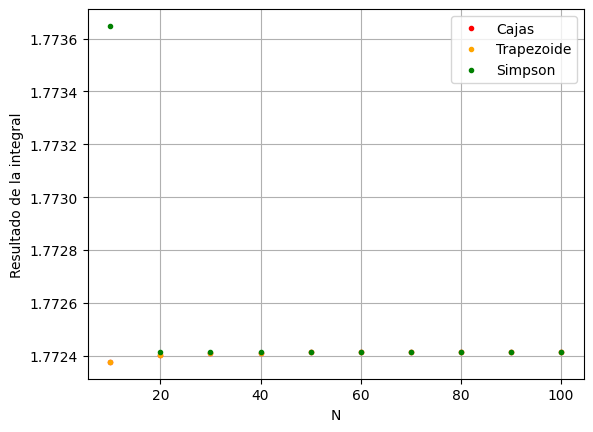

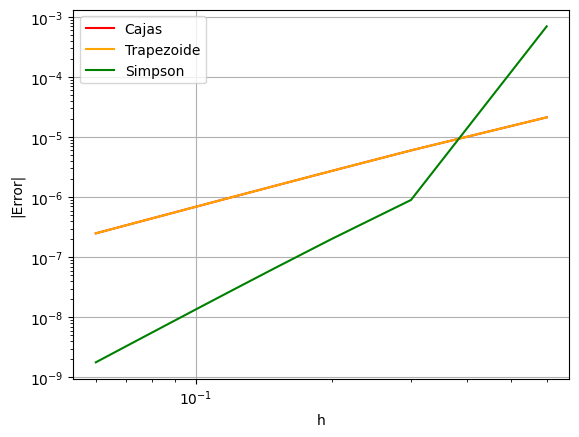

In [ ]:
# --- --- --- --- ---
#Para C: [−3,3]
h_C = (3-(-3))/N

exacta_C = i_exacta(-3, 3)

cajas_C = []
trapezoide_C = []
simpson_C = []

e_cajas_C = []
e_trapezoide_C = []
e_simpson_C = []

for n in N:
  #Calculo de resultados
  c_C = i_cajas(-3, 3, n)
  t_C = i_trapez(-3, 3, n)
  s_C = i_simpson(-3, 3, n)

  cajas_C.append(c_C)
  trapezoide_C.append(t_C)
  simpson_C.append(s_C)

  #Calculo de errores
  e_c_C = error_rel(exacta_C, c_C)
  e_t_C = error_rel(exacta_C, t_C)
  e_s_C = error_rel(exacta_C, s_C)

  e_cajas_C.append(e_c_C)
  e_trapezoide_C.append(e_t_C)
  e_simpson_C.append(e_s_C)

#Graficamos
#Gráfico de resultados
print("--- --- ---")
print("Intervalo C:")

plt.plot(N, cajas_C, ".", color = "red", label = "Cajas")
plt.plot(N, trapezoide_C, ".", color = "orange", label = "Trapezoide")
plt.plot(N, simpson_C, ".", color = "green", label = "Simpson")

plt.ylabel("Resultado de la integral")
plt.xlabel("N")

plt.legend()
plt.grid()
plt.savefig("C.png", dpi=300, bbox_inches="tight")
plt.show()

#Gráfico de error
plt.loglog(h_C, e_cajas_C, "-", color = "red", label = "Cajas")
plt.loglog(h_C, e_trapezoide_C, "-", color = "orange", label = "Trapezoide")
plt.loglog(h_C, e_simpson_C, "-", color = "green", label = "Simpson")

plt.ylabel("|Error|")
plt.xlabel("h")

plt.legend()
plt.grid()
plt.savefig("eC.png", dpi=300, bbox_inches="tight")
plt.show()

**Parte 2:**

Se ha obtenido una precisión de 0.005331760883702463 con un esquema de 5 puntos.


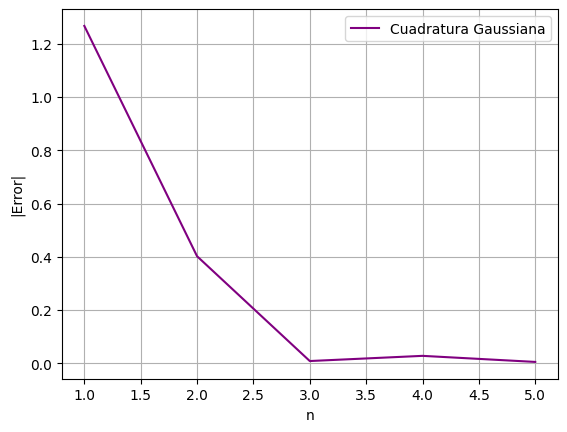

In [ ]:
# --- --- --- --- ---
#Cuadratura Gaussiana para B: [−2,2]
N_cuad = np.arange(1, 6, 1)

error_deseado = 0.01
reg_e = []

contador = 0

for n in N_cuad:
  I_i = cuadr_gauss(-2, 2, n)

  e_I_i = error_rel(exacta_B, I_i)
  reg_e.append(e_I_i)

print(f"Se ha obtenido una precisión de {reg_e[-1]} con un esquema de {N_cuad[-1]} puntos.")

#Gráfico de error
plt.plot(N_cuad, reg_e, "-", color = "purple", label = "Cuadratura Gaussiana")

plt.xlabel("n")
plt.ylabel("|Error|")

plt.legend()
plt.grid()
plt.savefig("gaussB.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# --- --- --- --- ---
#Comparación con el Método del Punto Medio
intervalo = np.linspace(-2, 2, 10000)

#Máximo absoluto
max_2derivada = np.max(np.abs(f2(intervalo)))
#print(max_2derivada)

#Cálculo de h
h = np.sqrt( (reg_e[-1]*24) / (max_2derivada*(2-(-2))) )

#Cálculo de n: número de rectángulos
n = (2-(-2))/h

print(f"Son necesarios {n} rectángulos para obtener una precisión de {reg_e[-1]}.")


Son necesarios 31.627437474435006 rectángulos para obtener una precisión de 0.005331760883702463.
